In [ ]:
import requests
import pandas as pd
from datetime import datetime

def get_inflation_data(start_date: str, end_date: str) -> pd.DataFrame:
    """
    Fetch RBA inflation data, returning a DataFrame with a date column.
    start_date / end_date: must be in 'YYYY-MM-DD' format.
    """
    url = f"http://localhost:9090/inflation/rba?start={start_date}&end={end_date}"
    resp = requests.get(url)
    resp.raise_for_status()
    items = resp.json()
    records = [item['_source'] for item in items]
    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values('date').reset_index(drop=True)


def get_house_transfer(start_year: int, start_month: int,
                        end_year: int, end_month: int) -> pd.DataFrame:
    """
    Fetch median house transfer prices and counts data, returning a DataFrame with a date column.
    start_month / end_month: must be one of 3, 6, 9, 12.
    """
    url = f"http://localhost:9090/housetransfer/{start_year}/{start_month}/{end_year}/{end_month}"
    resp = requests.get(url)
    resp.raise_for_status()
    data = resp.json().get('Data', [])
    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df[['Year','Month']].assign(Day=1))
    return df


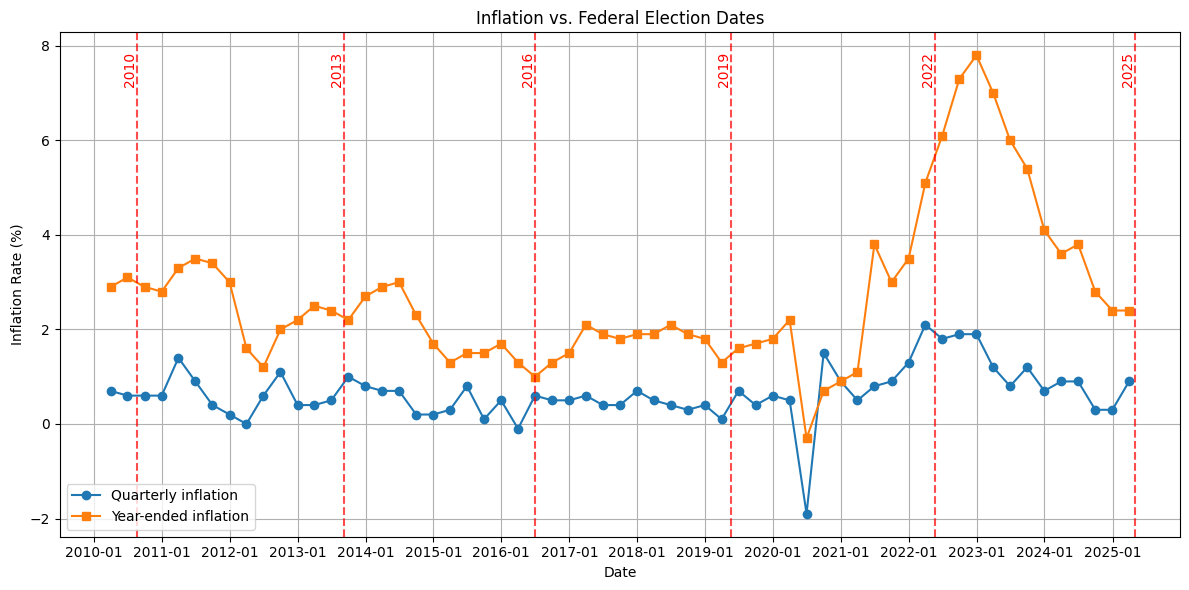

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Get Data
df_inf = get_inflation_data("2010-01-01", "2025-05-31")

# Define Election Day
election_dates = [
    datetime(2010, 8, 21),
    datetime(2013, 9, 7),
    datetime(2016, 7, 2),
    datetime(2019, 5, 18),
    datetime(2022, 5, 21),
    datetime(2025, 5, 3),
]

# Draw
plt.figure(figsize=(12, 6))
plt.plot(df_inf['date'], df_inf['Quarterly inflation'],
        marker='o', label='Quarterly inflation')
plt.plot(df_inf['date'], df_inf['Year-ended inflation'],
        marker='s', label='Year-ended inflation')

for ed in election_dates:
    plt.axvline(ed, color='red', linestyle='--', alpha=0.7)
    plt.text(ed, plt.ylim()[1]*0.95, ed.year,
            rotation=90, color='red',
            va='top', ha='right')

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.title('Inflation vs. Federal Election Dates')
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


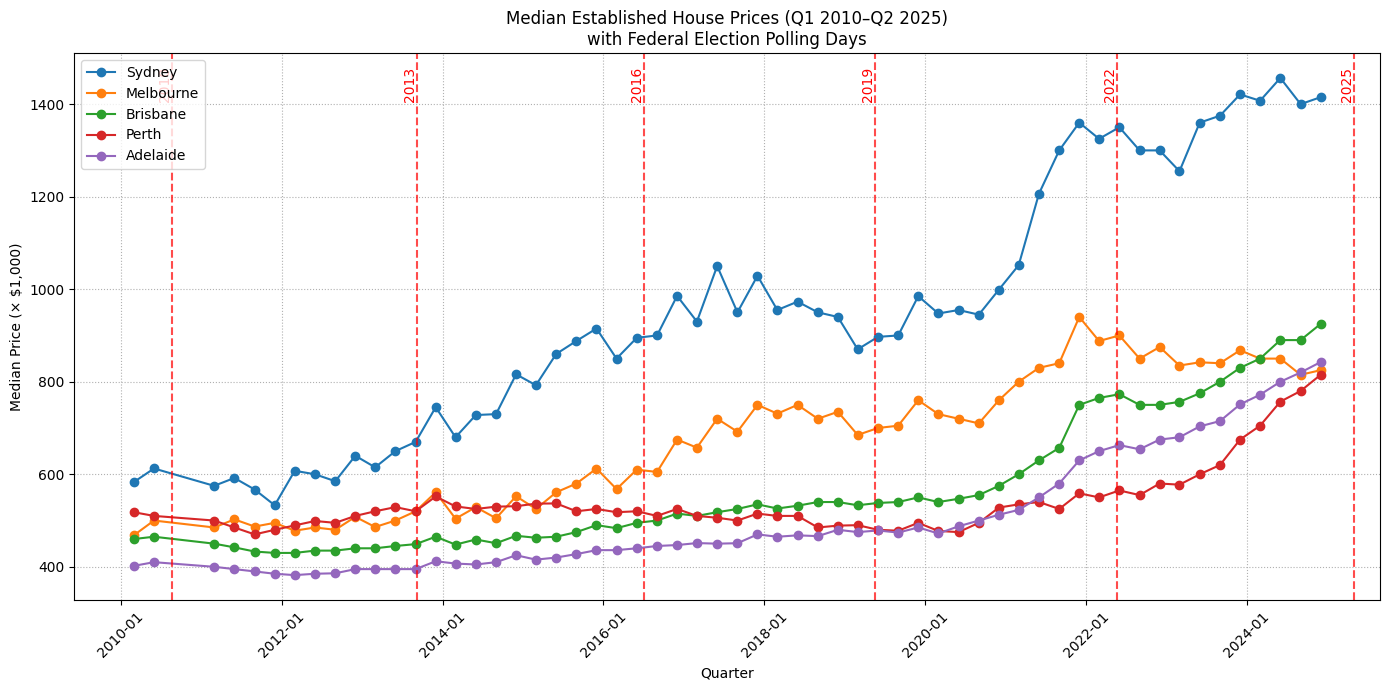

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Get Data
df_house = get_house_transfer(2010, 3, 2025, 6)

# Display Data of Main Cities
cities = ["Sydney", "Melbourne", "Brisbane", "Perth", "Adelaide"]
df_c = df_house[df_house.Region.isin(cities)]

# Define Election Day
election_dates = [
    datetime(2010, 8, 21),
    datetime(2013, 9, 7),
    datetime(2016, 7, 2),
    datetime(2019, 5, 18),
    datetime(2022, 5, 21),
    datetime(2025, 5, 3),
]

# Draw
plt.figure(figsize=(14, 7))
for city in cities:
    sub = df_c[df_c.Region == city]
    plt.plot(sub['date'], sub['Median_Est_House'],
            marker='o', label=city)

ymin, ymax = plt.ylim()
for ed in election_dates:
    plt.axvline(ed, color='red', linestyle='--', alpha=0.7)
    plt.text(ed, ymax*0.98, ed.year,
            rotation=90, color='red',
            va='top', ha='right')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.title('Median Established House Prices (Q1 2010–Q2 2025)\nwith Federal Election Polling Days')
plt.xlabel('Quarter')
plt.ylabel('Median Price (× $1,000)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()
